[INFO] Memuat Dataset STEAD_10000: STEAD_10000_Harmonized_Final.json


2026-07-19 05:51:49.915774: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-19 05:51:49.921120: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-19 05:51:49.921347: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-19 05:51:49.921595: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-19 05:51:49.921780: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
Estimating STEAD_10000 embeddings statistics (KDE)...
Memproses 20000 data STEAD 10000...
Inference STEAD 10000: 100%|██████████| 20000/20000 [02:59<00:00, 111.30it/s]


Accuracy: [0.396275, 0.396275]
Accuracy (avg.): 0.396275
True positive rate: [0.056, 0.73655]
True positive rate (avg.): 0.396275
True negative rate: [0.73655, 0.056]
True negative rate (avg.): 0.396275
Positive predictive value: [0.1753012991078416, 0.4382791348070572]
Positive predictive value (avg.): 0.3067902169574494
Negative predictive value: [0.4382791348070572, 0.1753012991078416]
Negative predictive value (avg.): 0.3067902169574494
False positive rate: [0.26345, 0.944]
False positive rate (avg.): 0.603725
False negative rate: [0.944, 0.26345]
False negative rate (avg.): 0.603725
False discovery rate: [0.8246987008921584, 0.5617208651929428]
False discovery rate (avg.): 0.6932097830425505
F1-score: [0.08488385312061844, 0.5495513980339857]
F1-score (avg.): 0.3172176255773021
[DEBUG] Nilai yang akan diplot: [0.396275, 0.396275, 0.3067902169574494, 0.603725, 0.3172176255773021]



STEAD_10000 ACCURACY: None
STEAD_10000 F1-SCORE: None
Pengujian STEAD_10000 Selesai.


[INFO] Grafik metrik komprehensif tersimpan di: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/stead_10000/nUUSS_embedding_1c_v2/MCU_Quake_1C_STEAD_10000_19055149/stead_10000_metrics_bar.jpg


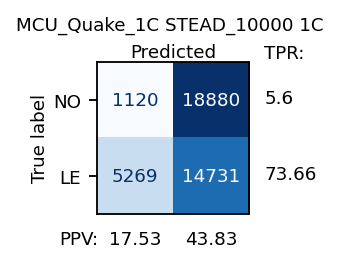

In [1]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt

# Fungsi untuk membuat diagram batang metrik komprehensif
def plot_comprehensive_metrics(metrics, save_path):
    # Mapping nama label ke key yang tepat sesuai output Anda
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    
    # Mengambil nilai berdasarkan key yang tepat
    values = [metrics.get(k, 0) for k in keys]
    
    print(f"[DEBUG] Nilai yang akan diplot: {values}") 

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Average)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Tambahkan angka di atas batang
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
                
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik komprehensif tersimpan di: {save_path}")

# Main execution
if __name__ == "__main__":
                  
    #===================================================================
    #                    1. KONFIGURASI PATH STEAD
    #===================================================================
    # Path dataset STEAD yang Bapak berikan
    KEY_DATA_DIR = '/Volumes/Extreme SSD/stream_stead/data_stead'
    KEY_TEST_FILE = 'STEAD_10000_Harmonized_Final.json'
    
    DATA_TAG = "STEAD_10000"
    MODEL_TAG = "MCU_Quake_1C"
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    
    # STEAD fokus pada Noise (NO) dan Earthquake (LE)
    true_labels = ["NO", "LE"]
    source_to_code = {"noise": 0, "le": 1}

    # Path Model dan Embedding (PASTIKAN MENGGUNAKAN EMBEDDING STEAD)
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    # Path Embedding Khusus STEAD (n=61099) atau UUSS (n=11275) opsi: gunakan salah satu, jangan keduanya
    #EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538")
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")
    #===================================================================
    #                           2. PREPARE FILES
    #===================================================================
    print(f"[INFO] Memuat Dataset STEAD_10000: {KEY_TEST_FILE}")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    SAVE_BASE = '/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/stead_10000/nUUSS_embedding_1c_v2'
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    if not os.path.exists(save_dir): os.makedirs(save_dir)

    # Logger
    log_file_path = os.path.join(save_dir, "task_log_stead_10000.txt")
    logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load Model & Embeddings STEAD
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

    logger.info(f"Estimating STEAD_10000 embeddings statistics (KDE)...")
    # Menggunakan statistik ruang laten STEAD_10000
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    #===================================================================
    #                            3. EVALUATION
    #===================================================================
    total_true_3C, total_pred_3C = [], []
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    keys_list = list(test_data.keys())

    logger.info(f"Memproses {len(keys_list)} data STEAD 10000...")

    for i in tqdm(range(len(keys_list)), desc="Inference STEAD 10000"):
        record_key = keys_list[i]
        record = test_data[record_key]
        quake_label = record["type"] # label asli: 'le'
    
        try:
            # Hanya ambil Z
            Z_n = record["Z_noise"][-num_points:]
            Z_s = record["Z"][:num_points]

            # Embedding Z saja
            _in_Zn = utils.latent_codes_1D(Z_n, embedding_model)
            _in_Zs = utils.latent_codes_1D(Z_s, embedding_model)

            # Karena model MCU-Quake 3C mengharapkan 3 komponen, 
            # kita berikan Z untuk ketiga slot input (E, N, Z) sebagai workaround
            emb_n = np.array([_in_Zn, _in_Zn, _in_Zn]).reshape(1,-1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zn, _in_Zn, _in_Zs]).reshape(1,-1) # Z_s untuk Z
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            total_true_3C.extend([0, 1]) 
            total_pred_3C.extend([1 if p_n >= 1 else 0, 1 if p_s >= 1 else 0])
            
        except Exception as e:
            logger.error(f"Error pada {record_key}: {e}")
            continue

    #===================================================================
    #                        4. METRICS & SAVE
    #===================================================================

    matrix_1C, metrics_1C = utils.calc_confusion_metrics(total_true_3C, total_pred_3C)
    
    # Visualisasi
    fig_1C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 1C ", true_labels, matrix_1C, metrics_1C)
    fig_1C.savefig(os.path.join(save_dir, "STEAD_10000_1C.jpg"), dpi=300)
    
    dataset.save_json_data(os.path.join(save_dir, "stead_10000_metrics.json"), metrics_1C)
    
    # Plot comprehensive metrics
    plot_comprehensive_metrics(metrics_1C, os.path.join(save_dir, "stead_10000_metrics_bar.jpg"))

    logger.info("\n" + "="*40)
    logger.info(f"STEAD_10000 ACCURACY: {metrics_1C.get('accuracy (avg.)')}")
    logger.info(f"STEAD_10000 F1-SCORE: {metrics_1C.get('f1-score (avg.)')}")
    logger.info("="*40)
    logger.info("Pengujian STEAD_10000 Selesai.")

    
    
   

[INFO] Memulai Investigasi Integritas Label STEAD 10000
[SUCCESS] Berhasil memuat 20000 records dari file JSON.

--- DISTRIBUSI LABEL RAW (Asli di JSON) ---
 -> 'no': 10000 data
 -> 'se': 10000 data

--- DISTRIBUSI LABEL TERNORMALISASI ---
 -> Derau (NO): 10000 data
 -> Gempa (LE): 10000 data

[INFO] Menggambar sampel acak untuk inspeksi visual...


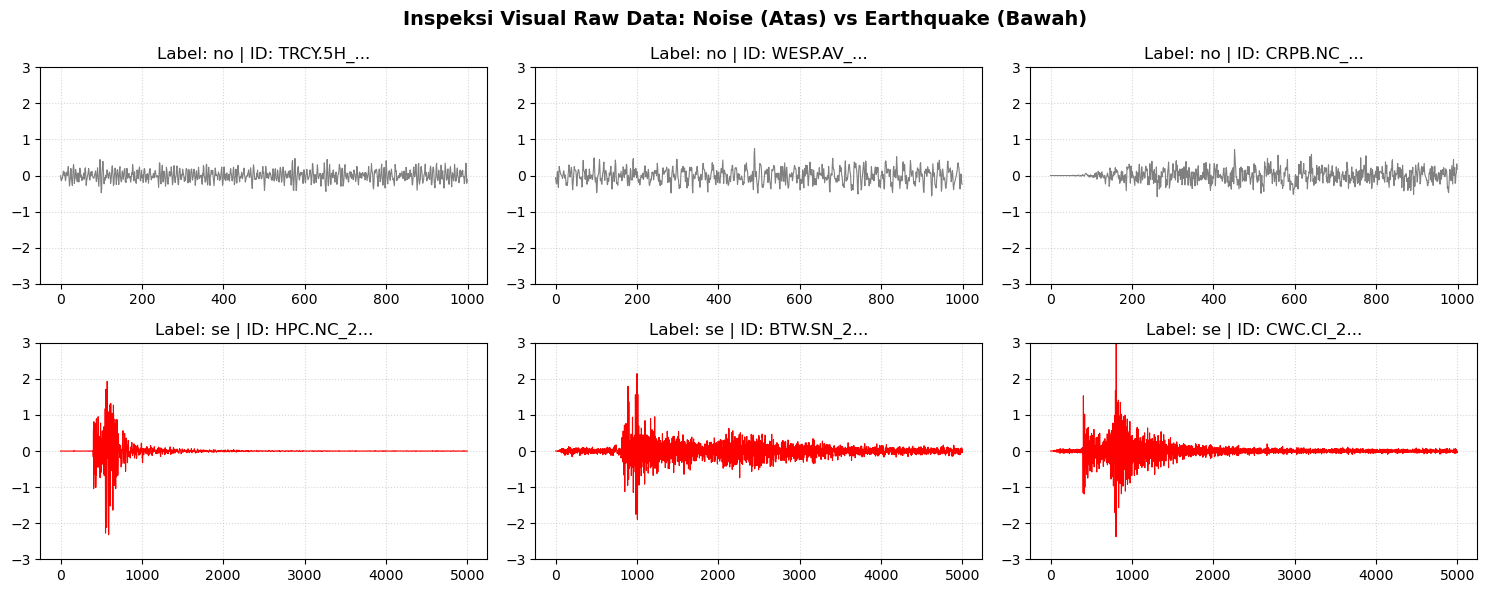

In [1]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def investigate_stead_labels():
    file_path = "/Volumes/Extreme SSD/stream_stead/data_stead/STEAD_10000_Harmonized_Final.json"
    
    print("="*60)
    print("[INFO] Memulai Investigasi Integritas Label STEAD 10000")
    print("="*60)
    
    # 1. Load Data
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        print(f"[SUCCESS] Berhasil memuat {len(data)} records dari file JSON.")
    except Exception as e:
        print(f"[ERROR] Gagal memuat file: {e}")
        return

    # 2. Hitung Distribusi Label
    raw_labels = []
    normalized_labels = []
    
    noise_keys = []
    eq_keys = []
    
    for key, record in data.items():
        # Cek ketersediaan key 'type'
        if "type" not in record:
            print(f"[WARNING] Record {key} tidak memiliki key 'type'")
            continue
            
        raw_label = record["type"]
        raw_labels.append(raw_label)
        
        # Normalisasi untuk perhitungan
        label_lower = str(raw_label).lower()
        if label_lower in ["le", "se", "eq", "earthquake", "qb"]:
            normalized_labels.append("Gempa (LE)")
            eq_keys.append(key)
        else:
            normalized_labels.append("Derau (NO)")
            noise_keys.append(key)

    print("\n--- DISTRIBUSI LABEL RAW (Asli di JSON) ---")
    raw_counts = Counter(raw_labels)
    for label, count in raw_counts.items():
        print(f" -> '{label}': {count} data")
        
    print("\n--- DISTRIBUSI LABEL TERNORMALISASI ---")
    norm_counts = Counter(normalized_labels)
    for label, count in norm_counts.items():
        print(f" -> {label}: {count} data")

    # 3. Inspeksi Visual Sinyal (Sanity Check)
    print("\n[INFO] Menggambar sampel acak untuk inspeksi visual...")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    fig.suptitle("Inspeksi Visual Raw Data: Noise (Atas) vs Earthquake (Bawah)", fontsize=14, fontweight='bold')
    
    # Plot 3 sampel Noise secara acak
    if len(noise_keys) >= 3:
        sample_noise = random.sample(noise_keys, 3)
        for i, k in enumerate(sample_noise):
            # Coba ambil Z_noise jika ada, jika tidak ambil Z
            sig = data[k].get("Z_noise", data[k].get("Z", [])) 
            axes[0, i].plot(sig, color='gray', linewidth=0.8)
            axes[0, i].set_title(f"Label: {data[k].get('type')} | ID: {k[:8]}...")
            axes[0, i].set_ylim(-3, 3) # Asumsi sinyal sudah dinormalisasi STD
            axes[0, i].grid(True, linestyle=':', alpha=0.5)
            
    # Plot 3 sampel Earthquake secara acak
    if len(eq_keys) >= 3:
        sample_eq = random.sample(eq_keys, 3)
        for i, k in enumerate(sample_eq):
            sig = data[k].get("Z", [])
            axes[1, i].plot(sig, color='red', linewidth=0.8)
            axes[1, i].set_title(f"Label: {data[k].get('type')} | ID: {k[:8]}...")
            axes[1, i].set_ylim(-3, 3)
            axes[1, i].grid(True, linestyle=':', alpha=0.5)
            
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    investigate_stead_labels()

[INFO] Memulai Investigasi Integritas Data Target (Indonesia)
[SUCCESS] Berhasil memuat 12939 records dari file JSON Indonesia.

--- DISTRIBUSI LABEL RAW (Data Indonesia) ---
 -> 'se': 12939 data

[INFO] Total record yang memiliki pasang Z dan Z_noise: 12939

[INFO] Menggambar sampel acak untuk inspeksi visual...


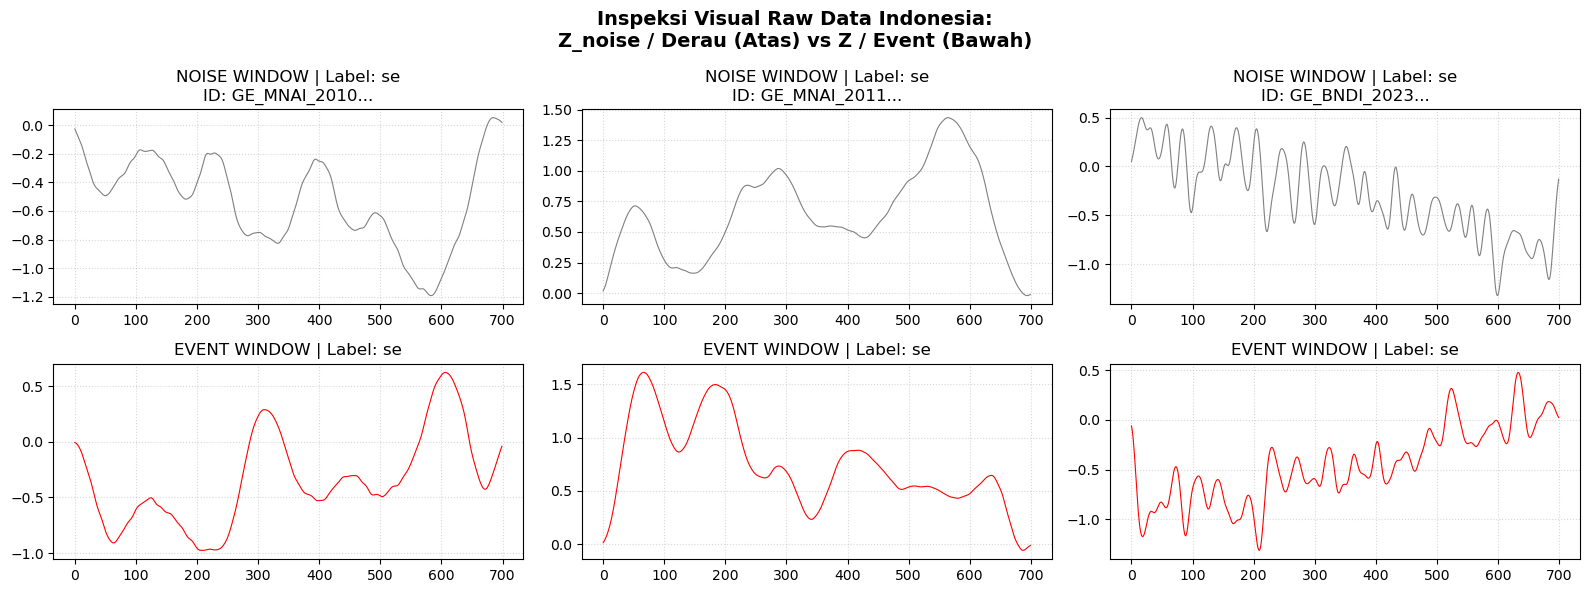

[INFO] Inspeksi selesai.


In [4]:
import json
import random
import matplotlib.pyplot as plt
from collections import Counter

def investigate_indonesia_data():
    file_path = "/Volumes/Extreme SSD/output_json_indonesia/extracted_data_3comp.json"
    
    print("="*65)
    print("[INFO] Memulai Investigasi Integritas Data Target (Indonesia)")
    print("="*65)
    
    # 1. Load Data
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        print(f"[SUCCESS] Berhasil memuat {len(data)} records dari file JSON Indonesia.")
    except Exception as e:
        print(f"[ERROR] Gagal memuat file: {e}")
        return

    # 2. Hitung Distribusi Ketersediaan Key
    raw_labels = []
    valid_keys = []
    
    for key, record in data.items():
        if "type" in record:
            raw_labels.append(record["type"])
            
        # Memastikan record memiliki Z (Event) dan Z_noise (Derau) untuk diuji
        if "Z" in record and "Z_noise" in record:
            valid_keys.append(key)

    print("\n--- DISTRIBUSI LABEL RAW (Data Indonesia) ---")
    raw_counts = Counter(raw_labels)
    for label, count in raw_counts.items():
        print(f" -> '{label}': {count} data")
        
    print(f"\n[INFO] Total record yang memiliki pasang Z dan Z_noise: {len(valid_keys)}")

    # 3. Inspeksi Visual Sinyal (Sanity Check)
    print("\n[INFO] Menggambar sampel acak untuk inspeksi visual...")
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 6))
    fig.suptitle("Inspeksi Visual Raw Data Indonesia:\nZ_noise / Derau (Atas) vs Z / Event (Bawah)", fontsize=14, fontweight='bold')
    
    # Ambil 3 sampel acak
    if len(valid_keys) >= 3:
        sample_keys = random.sample(valid_keys, 3)
        
        for i, k in enumerate(sample_keys):
            record = data[k]
            label = record.get('type', 'N/A')
            
            z_noise_sig = record["Z_noise"]
            z_sig = record["Z"]
            
            # Plot Z_noise di baris atas
            axes[0, i].plot(z_noise_sig, color='gray', linewidth=0.8)
            axes[0, i].set_title(f"NOISE WINDOW | Label: {label}\nID: {k[:12]}...")
            # axes[0, i].set_ylim(-3, 3) # Opsional: uncomment jika sinyal sudah dinormalisasi
            axes[0, i].grid(True, linestyle=':', alpha=0.5)
            
            # Plot Z (Sinyal Event) di baris bawah
            axes[1, i].plot(z_sig, color='red', linewidth=0.8)
            axes[1, i].set_title(f"EVENT WINDOW | Label: {label}")
            # axes[1, i].set_ylim(-3, 3) # Opsional: uncomment jika sinyal sudah dinormalisasi
            axes[1, i].grid(True, linestyle=':', alpha=0.5)
            
    plt.tight_layout()
    plt.show()
    print("[INFO] Inspeksi selesai.")

if __name__ == "__main__":
    investigate_indonesia_data()